In [1]:
from google.colab import files
upload = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


First 5 Rows
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  

Shape of Dataset
(768, 7)

Columns
Index(['Region', ' Date', ' Freq

/tmp/ipykernel_8965/1731490173.py:27: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


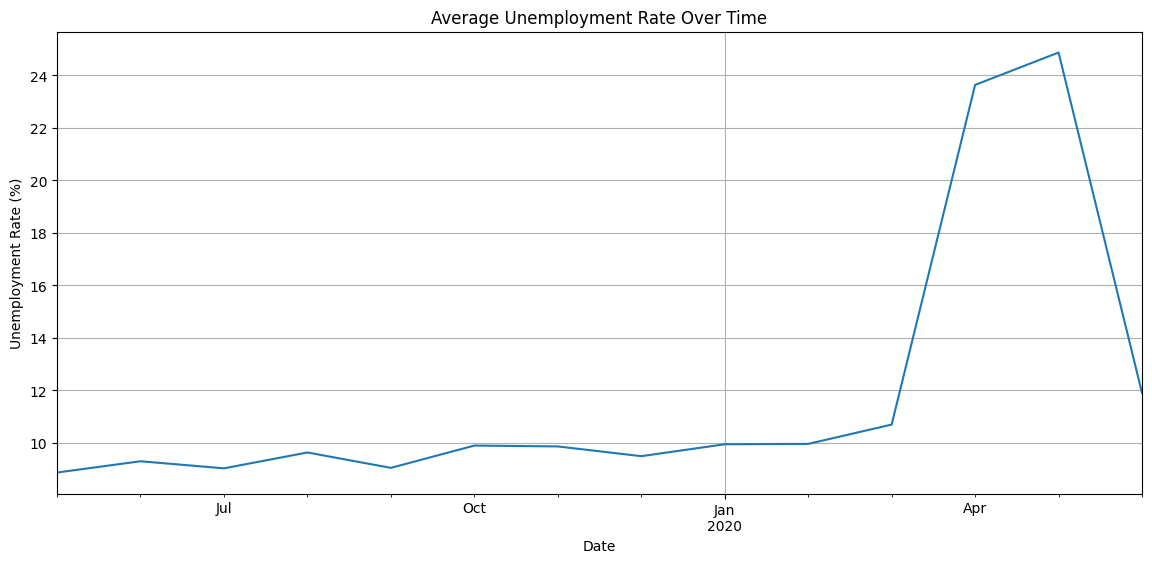


Average Unemployment Before Covid
9.509533582089553

Average Unemployment During Covid
17.774362745098042


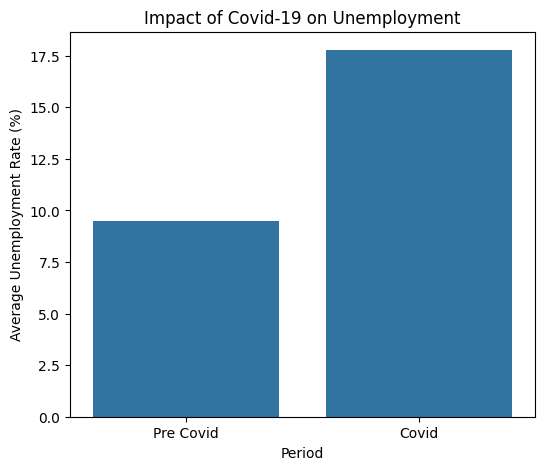

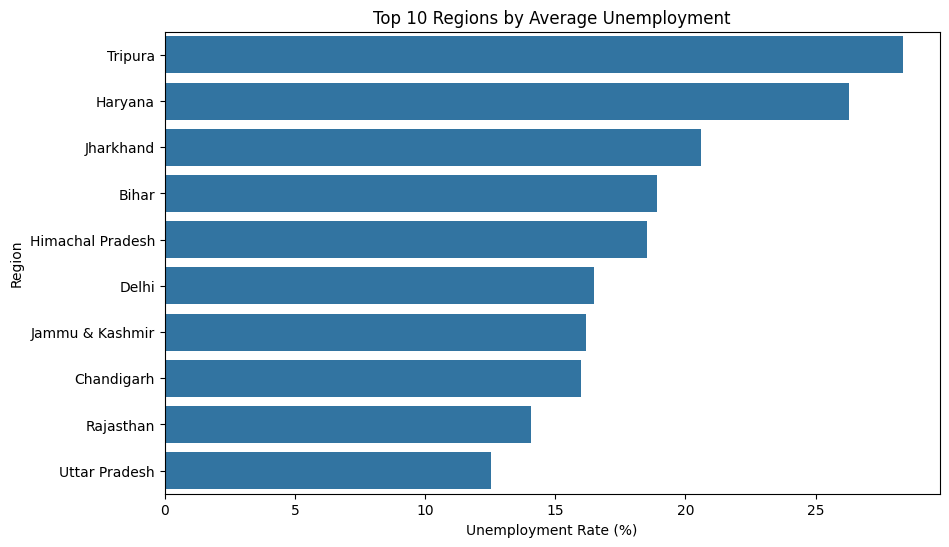

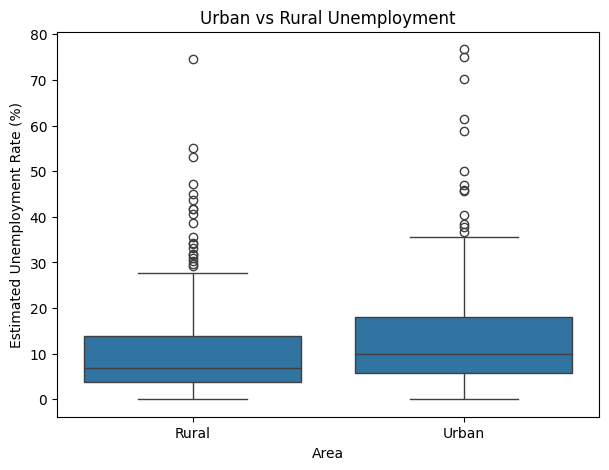

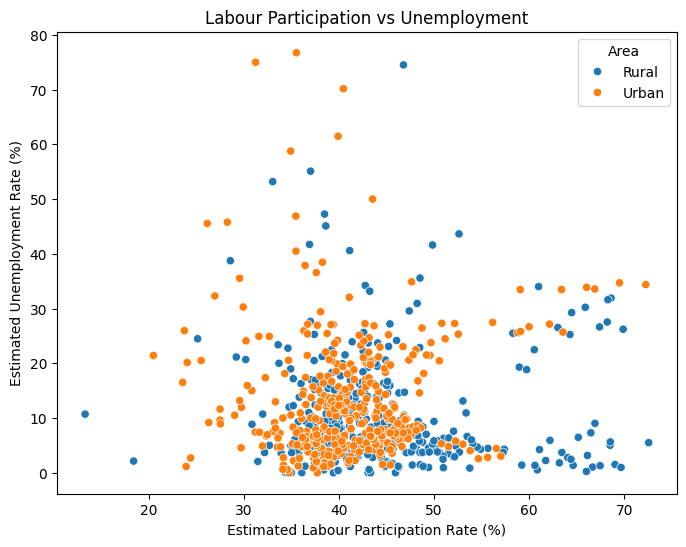

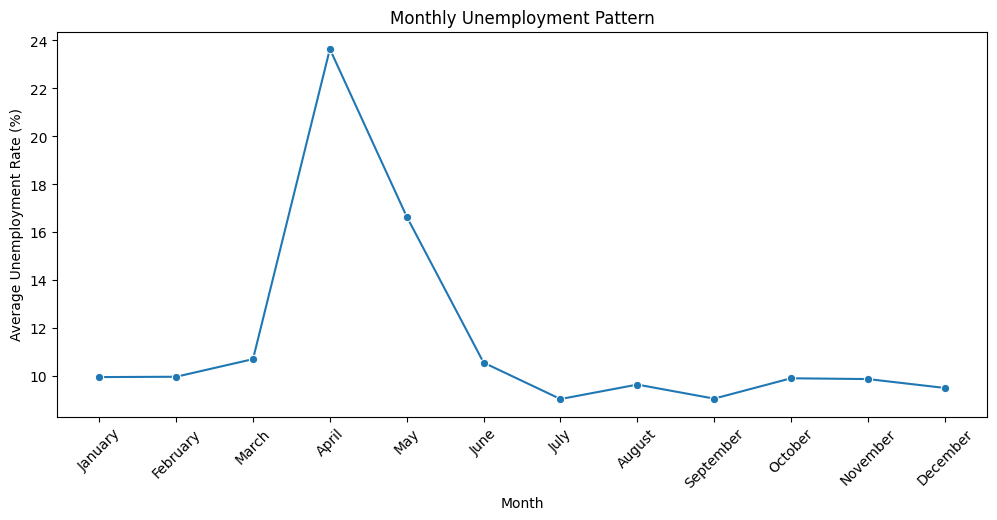

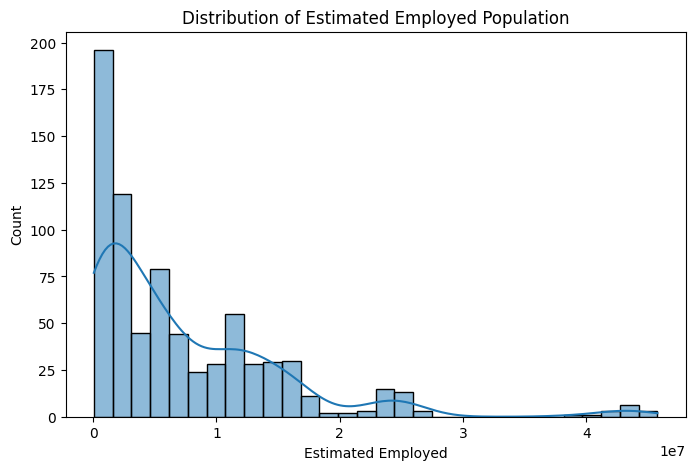

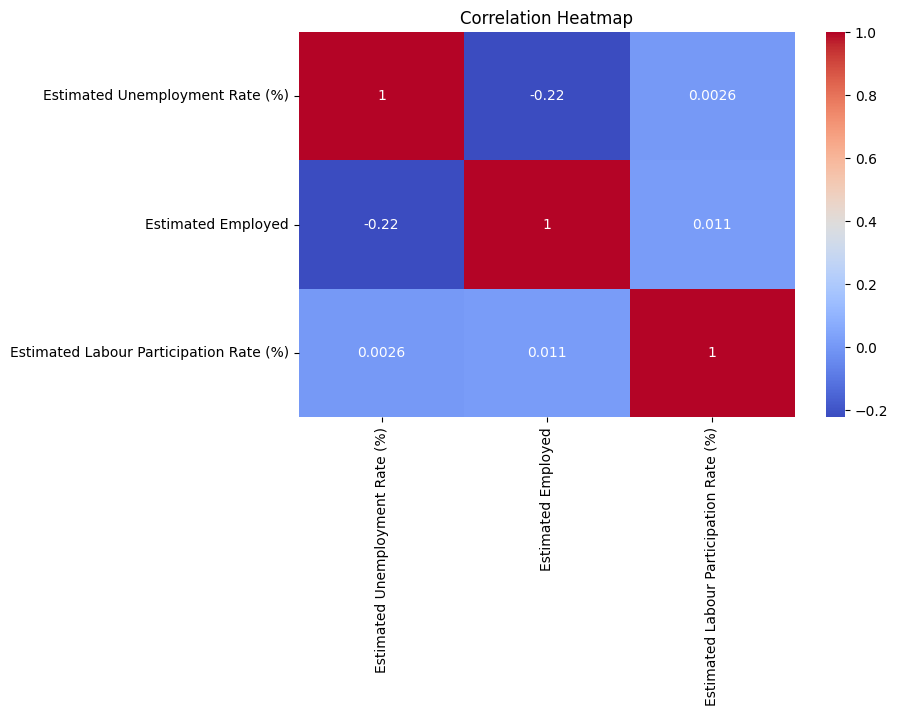


========== INSIGHTS ==========
1. Unemployment increased significantly during the Covid-19 period.
2. Certain states experienced much higher unemployment than others.
3. Urban and Rural areas show different unemployment patterns.
4. Labour participation and unemployment have a measurable relationship.
5. Monthly trends indicate seasonal fluctuations in unemployment.
6. These insights can help policymakers design employment programs.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Unemployment in India.csv")

print("First 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumns")
print(df.columns)

# ==========================================
# DATA CLEANING
# ==========================================

df.columns = df.columns.str.strip()

df['Date'] = pd.to_datetime(df['Date'])

print("\nMissing Values")
print(df.isnull().sum())

print("\nDataset Info")
print(df.info())

# ==========================================
# BASIC STATISTICS
# ==========================================

print("\nStatistical Summary")
print(df.describe())

# ==========================================
# UNEMPLOYMENT RATE TREND OVER TIME
# ==========================================

plt.figure(figsize=(14,6))

monthly_unemployment = df.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

monthly_unemployment.plot()

plt.title("Average Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True)
plt.show()

# ==========================================
# COVID-19 IMPACT ANALYSIS
# ==========================================

covid_period = df[df['Date'] >= '2020-03-01']
pre_covid = df[df['Date'] < '2020-03-01']

print("\nAverage Unemployment Before Covid")
print(pre_covid['Estimated Unemployment Rate (%)'].mean())

print("\nAverage Unemployment During Covid")
print(covid_period['Estimated Unemployment Rate (%)'].mean())

covid_comparison = pd.DataFrame({
    'Period':['Pre Covid','Covid'],
    'Unemployment Rate':[
        pre_covid['Estimated Unemployment Rate (%)'].mean(),
        covid_period['Estimated Unemployment Rate (%)'].mean()
    ]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=covid_comparison,
    x='Period',
    y='Unemployment Rate'
)

plt.title("Impact of Covid-19 on Unemployment")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

# ==========================================
# TOP 10 STATES WITH HIGHEST UNEMPLOYMENT
# ==========================================

state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

top10 = state_unemployment.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top10.values,
    y=top10.index
)

plt.title("Top 10 Regions by Average Unemployment")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("Region")
plt.show()

# ==========================================
# AREA WISE ANALYSIS
# ==========================================

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Urban vs Rural Unemployment")
plt.show()

# ==========================================
# LABOUR PARTICIPATION ANALYSIS
# ==========================================

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    hue='Area'
)

plt.title("Labour Participation vs Unemployment")
plt.show()

# ==========================================
# MONTHLY TREND
# ==========================================

df['Month'] = df['Date'].dt.month_name()

monthly_pattern = df.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

month_order = [
    'January','February','March','April',
    'May','June','July','August',
    'September','October','November','December'
]

monthly_pattern = monthly_pattern.reindex(month_order)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly_pattern.index,
    y=monthly_pattern.values,
    marker='o'
)

plt.xticks(rotation=45)
plt.title("Monthly Unemployment Pattern")
plt.ylabel("Average Unemployment Rate (%)")
plt.show()

# ==========================================
# EMPLOYMENT DISTRIBUTION
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated Employed'],
    bins=30,
    kde=True
)

plt.title("Distribution of Estimated Employed Population")
plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(8,5))

corr = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

# ==========================================
# KEY INSIGHTS
# ==========================================

print("\n========== INSIGHTS ==========")

print(
    "1. Unemployment increased significantly during the Covid-19 period."
)

print(
    "2. Certain states experienced much higher unemployment than others."
)

print(
    "3. Urban and Rural areas show different unemployment patterns."
)

print(
    "4. Labour participation and unemployment have a measurable relationship."
)

print(
    "5. Monthly trends indicate seasonal fluctuations in unemployment."
)

print(
    "6. These insights can help policymakers design employment programs."
)